# Exploratory Data Analysis

This notebook performs exploratory data analysis on the cleaned student dataset to identify patterns, relationships, and factors associated with career readiness and placement outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("=" * 60)
print("LOADING PROCESSED DATA FOR EDA")
print("=" * 60)

train_df = pd.read_csv("../data/processed/train_cleaned.csv")
test_df = pd.read_csv("../data/processed/test_cleaned.csv")

print("✅ Cleaned training dataset loaded successfully!")
print("✅ Cleaned testing dataset loaded successfully!")

print("\nDATASET DIMENSIONS")
print("-" * 60)
print(f"Training dataset : {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Testing dataset  : {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")

LOADING PROCESSED DATA FOR EDA
✅ Cleaned training dataset loaded successfully!
✅ Cleaned testing dataset loaded successfully!

DATASET DIMENSIONS
------------------------------------------------------------
Training dataset : 45,000 rows × 15 columns
Testing dataset  : 5,000 rows × 15 columns


## 4.1 Dataset Overview

The cleaned training dataset is examined to understand its structure, dimensions, and feature composition before performing detailed exploratory analysis.

In [2]:
print("=" * 60)
print("EDA DATASET OVERVIEW")
print("=" * 60)

print(f"Rows    : {train_df.shape[0]:,}")
print(f"Columns : {train_df.shape[1]}")

print("\nFeature Types")
print("-" * 60)

print(train_df.dtypes)

EDA DATASET OVERVIEW
Rows    : 45,000
Columns : 15

Feature Types
------------------------------------------------------------
Student_ID                int64
Age                       int64
Gender                   object
Degree                   object
Branch                   object
CGPA                    float64
Internships               int64
Projects                  int64
Coding_Skills             int64
Communication_Skills      int64
Aptitude_Test_Score       int64
Soft_Skills_Rating        int64
Certifications            int64
Backlogs                  int64
Placement_Status         object
dtype: object


## 4.2 CGPA and Placement Status

The relationship between students' CGPA and placement outcomes is analyzed to determine whether academic performance is associated with placement success.

In [3]:
print("=" * 60)
print("CGPA VS PLACEMENT STATUS")
print("=" * 60)

cgpa_placement = train_df.groupby("Placement_Status")["CGPA"].mean()

print(cgpa_placement)

CGPA VS PLACEMENT STATUS
Placement_Status
Not Placed    6.633941
Placed        7.650109
Name: CGPA, dtype: float64


### CGPA Comparison by Placement Status

The average CGPA of placed and non-placed students is visualized to clearly compare their academic performance.

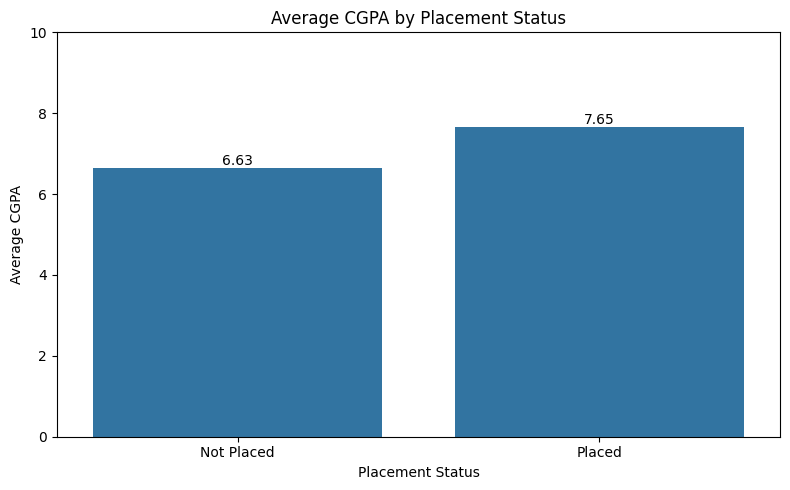

In [4]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=train_df,
    x="Placement_Status",
    y="CGPA",
    estimator="mean",
    errorbar=None
)

plt.title("Average CGPA by Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.ylim(0, 10)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Internships and Placement Status

The relationship between the number of internships completed by students and their placement outcomes is analyzed to understand whether practical industry exposure is associated with placement success.

In [5]:
print("=" * 60)
print("INTERNSHIPS VS PLACEMENT STATUS")
print("=" * 60)

internship_placement = train_df.groupby("Placement_Status")["Internships"].mean()

print(internship_placement)

INTERNSHIPS VS PLACEMENT STATUS
Placement_Status
Not Placed    0.579406
Placed        1.116479
Name: Internships, dtype: float64


### Internship Distribution by Placement Status

The distribution of students across different internship levels is analyzed to compare placement outcomes and identify potential gaps in practical industry exposure.

In [6]:
print("=" * 60)
print("INTERNSHIP DISTRIBUTION BY PLACEMENT STATUS")
print("=" * 60)

internship_placement_pct = pd.crosstab(
    train_df["Internships"],
    train_df["Placement_Status"],
    normalize="index"
) * 100

print(internship_placement_pct.round(2))

INTERNSHIP DISTRIBUTION BY PLACEMENT STATUS
Placement_Status  Not Placed  Placed
Internships                         
0                      79.09   20.91
1                      55.65   44.35
2                      44.28   55.72
3                      32.75   67.25


C:\Users\HARSHADA\AppData\Local\Temp\ipykernel_8872\1646271072.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Placement Status")


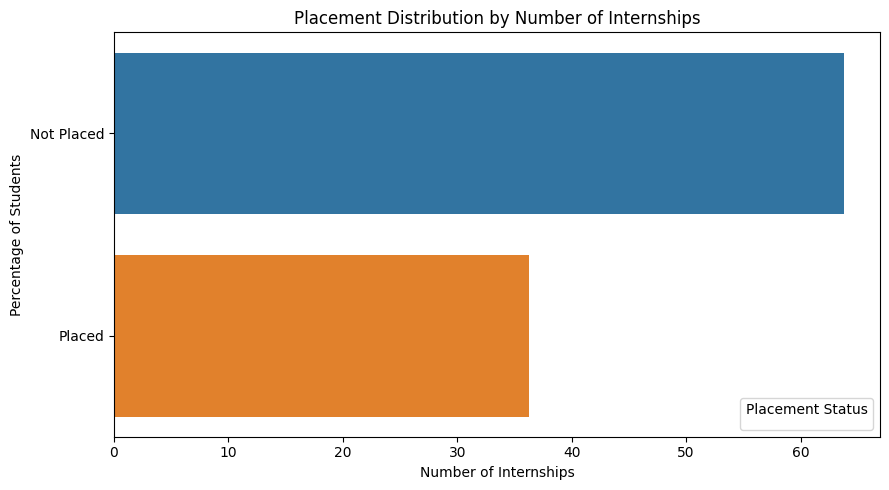

In [10]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=train_df,
    x="Internships",
    y="Placement_Status",
    hue="Placement_Status",
    estimator=lambda x: len(x) / len(train_df) * 100,
    errorbar=None
)

plt.title("Placement Distribution by Number of Internships")
plt.xlabel("Number of Internships")
plt.ylabel("Percentage of Students")

plt.legend(title="Placement Status")

plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

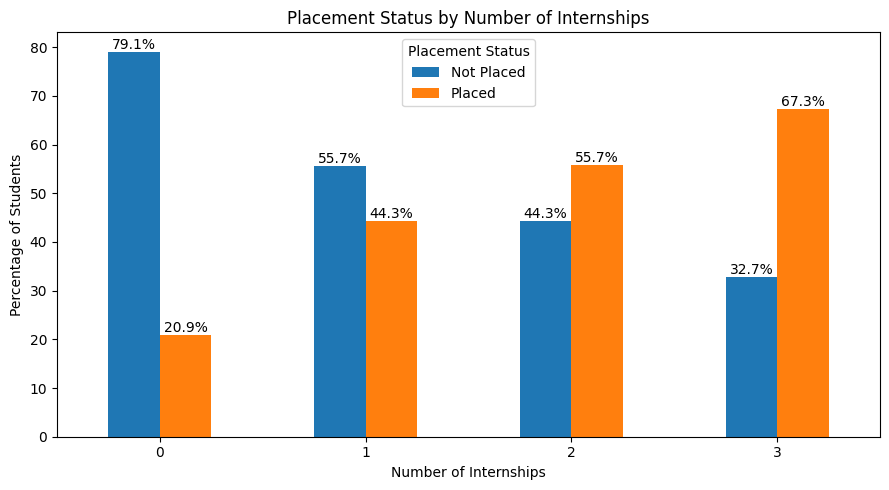

In [11]:
plt.figure(figsize=(9, 5))

ax = internship_placement_pct.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Placement Status by Number of Internships")
plt.xlabel("Number of Internships")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.legend(title="Placement Status")
plt.tight_layout()
plt.show()

###📌 Report Insight

Internship experience shows a strong positive association with placement outcomes. Students with greater internship exposure have a higher proportion of successful placements, indicating that practical industry exposure may be an important area of career readiness.

### Projects and Placement Status

The relationship between the number of projects completed by students and their placement outcomes is analyzed to evaluate the role of practical project experience in career readiness.

In [12]:
print("=" * 60)
print("PROJECTS VS PLACEMENT STATUS")
print("=" * 60)

projects_placement = train_df.groupby("Placement_Status")["Projects"].mean()

print(projects_placement)


PROJECTS VS PLACEMENT STATUS
Placement_Status
Not Placed    3.385388
Placed        4.347719
Name: Projects, dtype: float64


### Project Experience and Placement Distribution

The placement distribution across different levels of project experience is analyzed to identify whether practical project exposure is associated with improved placement outcomes.

In [13]:
print("=" * 60)
print("PROJECT DISTRIBUTION BY PLACEMENT STATUS")
print("=" * 60)

projects_placement_pct = pd.crosstab(
    train_df["Projects"],
    train_df["Placement_Status"],
    normalize="index"
) * 100

print(projects_placement_pct.round(2))

PROJECT DISTRIBUTION BY PLACEMENT STATUS
Placement_Status  Not Placed  Placed
Projects                            
1                     100.00    0.00
2                     100.00    0.00
3                      92.47    7.53
4                      49.42   50.58
5                      32.96   67.04
6                      24.62   75.38


<Figure size 900x500 with 0 Axes>

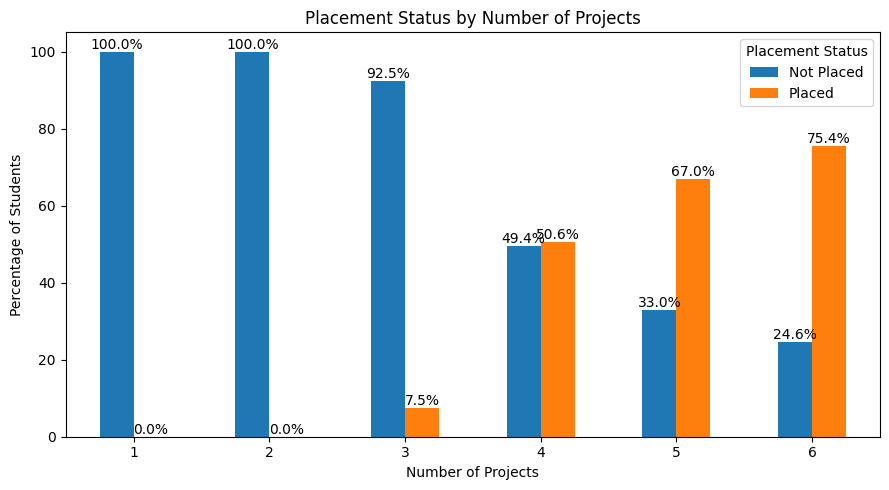

In [14]:
plt.figure(figsize=(9, 5))

ax = projects_placement_pct.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Placement Status by Number of Projects")
plt.xlabel("Number of Projects")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.legend(title="Placement Status")
plt.tight_layout()
plt.show()

### Coding Skills and Placement Status

The relationship between students' coding skill levels and placement outcomes is analyzed to determine whether technical proficiency is associated with improved placement outcomes.

In [15]:
print("=" * 60)
print("CODING SKILLS VS PLACEMENT STATUS")
print("=" * 60)

coding_placement = train_df.groupby("Placement_Status")["Coding_Skills"].mean()

print(coding_placement)

CODING SKILLS VS PLACEMENT STATUS
Placement_Status
Not Placed    5.030919
Placed        6.854095
Name: Coding_Skills, dtype: float64


Key Insight

Finding: Placed students have a higher average coding skill score (6.85) than non-placed students (5.03). This indicates a strong positive association between coding proficiency and placement outcomes in the dataset.

### Coding Skill Level and Placement Distribution

The placement distribution across different coding skill levels is analyzed to identify patterns in technical skill proficiency and placement outcomes.

In [16]:
print("=" * 60)
print("CODING SKILL DISTRIBUTION BY PLACEMENT STATUS")
print("=" * 60)

coding_placement_pct = pd.crosstab(
    train_df["Coding_Skills"],
    train_df["Placement_Status"],
    normalize="index"
) * 100

print(coding_placement_pct.round(2))

CODING SKILL DISTRIBUTION BY PLACEMENT STATUS
Placement_Status  Not Placed  Placed
Coding_Skills                       
1                     100.00    0.00
2                     100.00    0.00
3                     100.00    0.00
4                     100.00    0.00
5                      58.85   41.15
6                      53.51   46.49
7                      47.40   52.60
8                      41.39   58.61
9                      37.51   62.49
10                     32.73   67.27


<Figure size 1000x500 with 0 Axes>

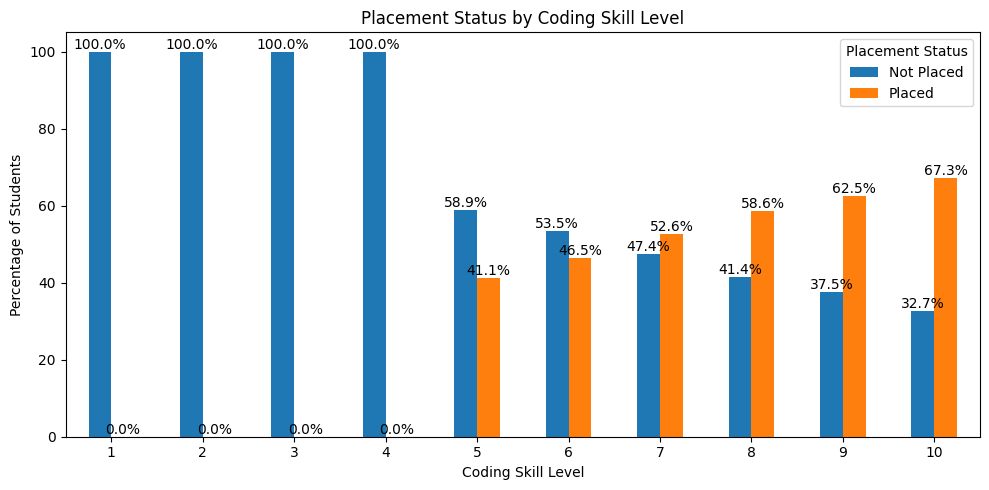

In [17]:
plt.figure(figsize=(10, 5))

ax = coding_placement_pct.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Placement Status by Coding Skill Level")
plt.xlabel("Coding Skill Level")
plt.ylabel("Percentage of Students")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.legend(title="Placement Status")
plt.tight_layout()
plt.show()